# Quick start from README

The example below runs the full EVV pipeline for formaldehyde.

### 1. Set up a vibrational N-wave mixing experiment

In [1]:
import wilson_suite.wilson_experiment.experiment_abstractions as wexp
from wilson_suite.wilson_derive.derive import get_fully_enhanced_terms
from wilson_suite.wilson_utils.termdict_from_symb_term import derived_terms_flat

# Here: Three pulses at different times, all X axis ("vertically") polarized. Two of the pulses are in the IR range
# and one is in the UV/VIS range. Corresponds to an "EVV" 2D-IR experiment.
pulse_ir_1 = wexp.make_impulsive_gaussian_pulse(tc=50.0, pol=(1.0, 0.0, 0.0), id=1)
pulse_ir_2 = wexp.make_impulsive_gaussian_pulse(tc=100.0, pol=(1.0, 0.0, 0.0), id=2)
pulse_uvvis_1 = wexp.make_impulsive_gaussian_pulse(tc=120.0, pol=(1.0, 0.0, 0.0), cf_uv=0.072, id=3)
field = wexp.ElectricField(pulses=(pulse_ir_1, pulse_ir_2, pulse_uvvis_1))

# Set the detector to detect vertically polarized light with the wavevector -k1 + k2 + k3
detector = wexp.SpecDetector(
    detection_method='freq',
    wv_filter=[{1: -1, 2: 1, 3: 1}],
    detection_polarization=(1.0, 0.0, 0.0),
)

# Create the experiment instance
experiment = wexp.VibExperiment(field=field, detector=detector, scans=(), magn_conditions=((-1, 2),),)

# Derive the relevant contributing terms, here return data as "flat" list for ease of inspection
evv_terms = derived_terms_flat(get_fully_enhanced_terms(experiment), tolistonly=True)

### 2. Derive response function terms

Based on the experiment, derive the symbolic response function terms, then
translate them to your chosen spectral axis variables.

In [2]:
import wilson_suite as ws
from wilson_suite.wilson_utils.some_reprs import make_SpectralAxisSet
from wilson_suite.wilson_utils.paths import SUITE_ROOT

# Derive the relevant contributing terms, here return in default structure (ordered by anharmonicity)
terms = ws.derive.derive.get_fully_enhanced_terms(experiment=experiment)

# Make an axis choice using w_1 and (-w_1 + w_2) as the 2D spectrum axes, 
# and translate the contributing terms to these variables A and B 
axis_choice = make_SpectralAxisSet({'A': [1], 'B': [-1, 2]})
translated_terms = ws.derive.term_var_translate.translate_terms_to_axis_variables(terms, axis_choice)

### 2. Configure the simulation

In [3]:
from wilson_suite.wilson_utils.wilson_data_obtainer import wilson_data_obtainer
from wilson_suite.wilson_analysis.render.render_utils import NormalizationType
from wilson_suite.wilson_intensities.amplitudes.spectrum_composition import SpectralWindow, Box

# Create a WilsonSimulation instance and add the experiment and (translated to axes choice) terms as attributes
# WilsonSimulation object stores simulation parameters and supports the full workflow from input to evaluation and/or rendering result
sim = ws.main.workflow_abstractions.WilsonSimulation()
sim.addExperiment(experiment)
sim.addTerms(terms=translated_terms)

# Add a molecular system (here formaldehyde) and other related setup information (vibrational energy level regime
# and location of quantum chemical data to be used)
sim.addSystem(ws.main.abstractions.MolecularSystem(name='FORM', natoms=4))
vibana = ws.main.abstractions.VibAnaSetup(system=sim.system, regime='GVPT2', vibana_own_analysis='none')
sim.addVibAnaSetup(vibana)
sim.addPropEvalSetup(eval_uniform=ws.main.abstractions.DataOriginInfo(
    source_type='gaussian',
    lvl_theory='B3LYP',
    basis_set='cc-pVQZ',
    base_file_loc=SUITE_ROOT + '/../data_for_tests/g16_formaldehyde_B3LYPcc_pVQZ.out',
))

# Add spectrum evaluation setup (lineshape parameter, evaluation dynamic range, spectral 
# grid resolution/evaluation window, and further rendering configuration (normalization type and output filename))
sim.addSpecEvalSetup(ws.main.spectrum_abstractions.SpecEvalSetup(
    ev_info=ws.main.spectrum_abstractions.EvaluationInfo(
        Gamma=4.7,
        Gamma_unit='cm-1',
        dynamic_range=500,
        grid_resolution={'A': 700, 'B': 700},
        spectral_window=SpectralWindow(box=Box({'A': (700., 3400.), 'B': (10., 3500.)})),
    ),
    rnd_info=ws.main.spectrum_abstractions.RenderingInfo(
        intensity_normalization_type=NormalizationType.LOG_RATIO,
        filename='evv_spectrum.svg',
    ),
))

### 3. Evaluate and render

In [4]:
# Determine which quantum chemical properties are needed to evaluate the contributing terms, obtain them from the
# previously specified source, and specify normal mode inclusion regime
sim.setPropsAndMaxStateLvl()
sim.dressPropsWithSetup()
sim.getResults(obtainer=wilson_data_obtainer)
sim.vib_ana_setup.set_include_modes_list()

# Register the axis choice and the contributing terms "in terms of" this axis choice, then evaluate the spectral amplitudes
sim.axis_choice = axis_choice
sim.terms_in_axis_choice = translated_terms
sim.evaluate()

# Render the spectrum
sim.spec_eval_setup.rnd_info.style_config.figsize = (10, 10)
sim.render_spectrum(do_diagn=False)
# spectrum saved to evv_spectrum.svg


self.nc_sqrt_eigval is not None False
self.has_all_states False 


 -- A feature at the location Point(A=2726.813, B=1795.4030000000002) with featbox Box(bounds={'A': (2611.3239481379296, 2842.3020518620706), 'B': (1679.9139481379298, 1910.8920518620707)}, grid=None, has_grid=False)

 -- A feature at the location Point(A=2726.813, B=2618.477) with featbox Box(bounds={'A': (2611.3239481379296, 2842.3020518620706), 'B': (2502.9879481379294, 2733.9660518620703)}, grid=None, has_grid=False)

 -- A feature at the location Point(A=2682.765, B=2662.525) with featbox Box(bounds={'A': (2567.2759481379294, 2798.2540518620704), 'B': (2547.0359481379296, 2778.0140518620706)}, grid=None, has_grid=False)

 -- A feature at the location Point(A=2682.765, B=1865.1070000000004) with featbox Box(bounds={'A': (2567.2759481379294, 2798.2540518620704), 'B': (1749.61794813793, 1980.596051862071)}, grid=None, has_grid=False)

 -- A feature at the location Point(A=2682.765, B=2745.9249999999997) with featbox 

/home/vlev/monorepo/src/wilson_suite/wilson_analysis/render/matplotlib_renderer.py:67: UserWarning: Log scale: values of z <= 0 have been masked
  contour = ax.contourf(self.Xdata, self.Ydata,


### 4. Display rendered result in notebook

Contour plot figure file: evv_spectrum.svg


/home/vlev/monorepo/src/wilson_suite/wilson_analysis/render/matplotlib_renderer.py:67: UserWarning: Log scale: values of z <= 0 have been masked
  contour = ax.contourf(self.Xdata, self.Ydata,


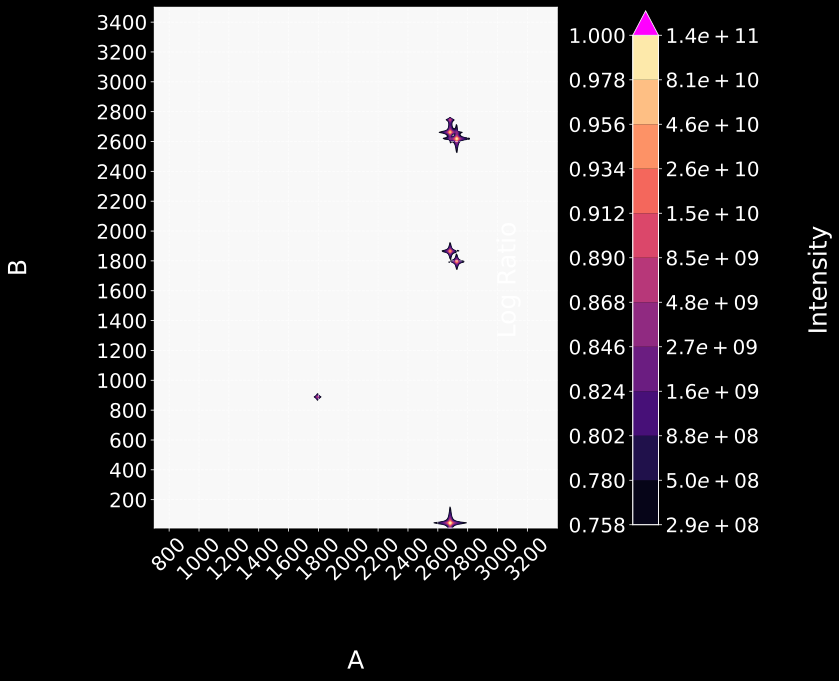

In [5]:
from IPython.display import SVG, display as ipydisplay

print(f'Contour plot figure file: {sim.spec_eval_setup.rnd_info.filename}')

sim.render_spectrum(do_diagn=False)
ipydisplay(SVG(sim.spec_eval_setup.rnd_info.filename))